# Log analysic

In [15]:
import logging
import random
import sys
from datetime import datetime, timedelta
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [16]:
ROOT = Path("..").resolve()
# print(ROOT)

RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)
now = datetime.now().replace(microsecond=0)

In [17]:
N_ROWS = 10_000
ANOMALY_RATE = 0.05
ANOMALY_N = int(N_ROWS * ANOMALY_RATE)   # ~500 rows

ENDPOINTS = ["/recommend", "/anomaly/detect", "/health"]
ENDPOINT_WEIGHTS = [0.55, 0.35, 0.10]

NORMAL_STATUS_CODES = [200, 400, 500]
NORMAL_STATUS_WEIGHTS = [0.92, 0.05, 0.03]

LATENCY_MEAN = 200.0   # ms
LATENCY_STD = 40.0
LATENCY_MIN = 10.0

ANOMALY_LATENCY_MIN = 3_000.0
ANOMALY_LATENCY_MAX = 8_000.0

OUT_DIR = Path().resolve().parent / "data" / "raw" / "logs"
OUT_FILE = OUT_DIR / "api_logs.csv"

RNG_SEED = 42

In [18]:
def _random_ip(rng: np.random.Generator) -> str:
    octets = rng.integers(1, 255, size=4)
    return ".".join(str(o) for o in octets)


def _timestamps(rng: np.random.Generator, n: int, now: datetime) -> list[datetime]:
    """Uniform-random timestamps over the last 30 days."""
    window = 30 * 24 * 3600  # seconds
    offsets = rng.integers(0, window, size=n)
    return [now - timedelta(seconds=int(s)) for s in offsets]


In [ ]:
latencies = rng.normal(LATENCY_MEAN, LATENCY_STD, size=ANOMALY_N).clip(min=LATENCY_MIN)
test = pd.DataFrame(
        {
            "timestamp": _timestamps(rng, ANOMALY_N, now),
            "user_id": rng.integers(1, 1001, size=ANOMALY_N),
            "endpoint": rng.choice(ENDPOINTS, size=ANOMALY_N, p=ENDPOINT_WEIGHTS),
            "latency_ms": np.round(latencies, 1),
            "status_code": rng.choice(
                NORMAL_STATUS_CODES, size=ANOMALY_N, p=NORMAL_STATUS_WEIGHTS
            ),
            "ip_address": [_random_ip(rng) for _ in range(ANOMALY_N)],
            "is_anomaly": False,
        }
    )

In [20]:
test

,timestamp,user_id,endpoint,latency_ms,status_code,ip_address,is_anomaly
0,2026-05-08 10:13:47,114,/anomaly/detect,212.2,200,198.171.237.244,False
1,2026-04-17 21:14:31,652,/anomaly/detect,158.4,200,180.95.153.108,False
2,2026-04-21 11:11:56,963,/health,230.0,200,160.207.94.129,False
3,2026-04-27 22:29:53,868,/recommend,237.6,200,12.188.125.117,False
4,2026-04-28 02:43:10,275,/recommend,122.0,200,136.55.152.190,False
...,...,...,...,...,...,...,...
495,2026-04-28 17:26:20,627,/recommend,237.4,200,229.244.48.103,False
496,2026-05-07 12:53:12,527,/anomaly/detect,126.7,200,49.13.246.235,False
497,2026-04-29 21:04:40,361,/recommend,186.6,200,237.225.165.133,False
498,2026-04-13 07:25:49,962,/health,120.4,200,252.141.164.54,False


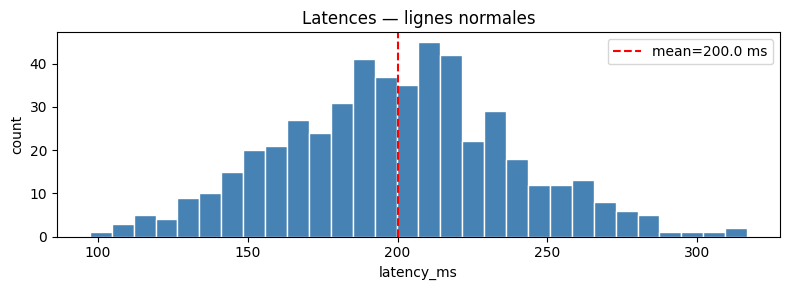

status_code
200    450
400     28
500     22
Name: count, dtype: int64
endpoint
/recommend         278
/anomaly/detect    169
/health             53
Name: count, dtype: int64


In [21]:
plt.figure(figsize=(8, 3))
plt.hist(test["latency_ms"], bins=30, color="steelblue", edgecolor="white")
plt.axvline(LATENCY_MEAN, color="red", linestyle="--", label=f"mean={LATENCY_MEAN} ms")
plt.xlabel("latency_ms")
plt.ylabel("count")
plt.title("Latences — lignes normales")
plt.legend()
plt.tight_layout()
plt.show()

print(test["status_code"].value_counts())
print(test["endpoint"].value_counts())

In [22]:
latencies = rng.uniform(ANOMALY_LATENCY_MIN, ANOMALY_LATENCY_MAX, size=ANOMALY_N)
high_latency_df = pd.DataFrame(
        {
            "timestamp": _timestamps(rng, ANOMALY_N, now),
            "user_id": rng.integers(1, 1001, size=ANOMALY_N),
            "endpoint": rng.choice(ENDPOINTS, size=ANOMALY_N, p=ENDPOINT_WEIGHTS),
            "latency_ms": np.round(latencies, 1),
            "status_code": rng.choice([200, 500], size=ANOMALY_N, p=[0.6, 0.4]),
            "ip_address": [_random_ip(rng) for _ in range(ANOMALY_N)],
            "is_anomaly": True,
        }
    )

In [23]:
high_latency_df.head()

,timestamp,user_id,endpoint,latency_ms,status_code,ip_address,is_anomaly
0,2026-04-22 12:40:11,122,/recommend,3169.4,500,114.5.171.116,True
1,2026-04-16 05:27:04,972,/anomaly/detect,6415.1,200,196.157.200.117,True
2,2026-04-21 21:33:01,512,/recommend,7752.5,500,3.34.117.101,True
3,2026-04-23 06:44:29,554,/anomaly/detect,7145.8,200,202.105.219.48,True
4,2026-04-27 01:59:34,414,/anomaly/detect,4386.0,200,98.193.32.82,True


In [25]:
burst_size = 10
n_bursts = max(1, ANOMALY_N // burst_size)
rows: list[dict] = []

for _ in range(n_bursts):
    burst_ip = _random_ip(rng)
    burst_start = now - timedelta(seconds=int(rng.integers(0, 30 * 24 * 3600)))
    for j in range(burst_size):
        rows.append(
            {
                "timestamp": burst_start + timedelta(seconds=j * int(rng.integers(1, 5))),
                "user_id": int(rng.integers(1, 1001)),
                "endpoint": rng.choice(ENDPOINTS, p=ENDPOINT_WEIGHTS),
                "latency_ms": round(float(np.clip(rng.normal(LATENCY_MEAN, LATENCY_STD), LATENCY_MIN, None)), 1),
                "status_code": 500,
                "ip_address": burst_ip,
                "is_anomaly": True,
            }
        )

# Preprocess

In [1]:
import logging
import pickle
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

In [6]:
FEATURE_COLS = [
    "hour",
    "latency_ms",
    "status_code",
    "user_request_freq",
    "user_error_ratio",
]

RAW_FILE = Path().resolve().parent / "data" / "raw" / "logs" / "api_logs.csv"

In [8]:
df = pd.read_csv(RAW_FILE, parse_dates=["timestamp"])
df.head()

,timestamp,user_id,endpoint,latency_ms,status_code,ip_address,is_anomaly
0,2026-04-11 03:02:32,95,/recommend,169.6,200,59.214.97.156,False
1,2026-04-11 03:04:11,246,/health,139.4,200,244.174.195.122,False
2,2026-04-11 03:07:43,860,/anomaly/detect,189.6,200,228.80.245.134,False
3,2026-04-11 03:08:53,999,/health,208.1,200,28.8.12.30,False
4,2026-04-11 03:12:38,362,/recommend,168.6,200,60.217.151.13,False


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   timestamp    10000 non-null  datetime64[us]
 1   user_id      10000 non-null  int64         
 2   endpoint     10000 non-null  str           
 3   latency_ms   10000 non-null  float64       
 4   status_code  10000 non-null  int64         
 5   ip_address   10000 non-null  str           
 6   is_anomaly   10000 non-null  bool          
dtypes: bool(1), datetime64[us](1), float64(1), int64(2), str(2)
memory usage: 478.6 KB


In [38]:
df["hour"] = df["timestamp"].dt.hour
freq = df["user_id"].map(df["user_id"].value_counts())
is_error = df["status_code"] >= 500
user_error = is_error.groupby(df["user_id"]).transform("sum")
ratio = (user_error / freq)
df["user_request_freq"] = freq
df["user_error_ratio"] = ratio

In [39]:
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   timestamp          10000 non-null  datetime64[us]
 1   user_id            10000 non-null  int64         
 2   endpoint           10000 non-null  str           
 3   latency_ms         10000 non-null  float64       
 4   status_code        10000 non-null  int64         
 5   ip_address         10000 non-null  str           
 6   is_anomaly         10000 non-null  bool          
 7   hour               10000 non-null  int32         
 8   user_request_freq  10000 non-null  int64         
 9   user_error_ratio   10000 non-null  float64       
dtypes: bool(1), datetime64[us](1), float64(2), int32(1), int64(3), str(2)
memory usage: 674.0 KB


,timestamp,user_id,endpoint,latency_ms,status_code,ip_address,is_anomaly,hour,user_request_freq,user_error_ratio
0,2026-04-11 03:02:32,95,/recommend,169.6,200,59.214.97.156,False,3,10,0.100000
1,2026-04-11 03:04:11,246,/health,139.4,200,244.174.195.122,False,3,8,0.000000
2,2026-04-11 03:07:43,860,/anomaly/detect,189.6,200,228.80.245.134,False,3,11,0.090909
3,2026-04-11 03:08:53,999,/health,208.1,200,28.8.12.30,False,3,18,0.000000
4,2026-04-11 03:12:38,362,/recommend,168.6,200,60.217.151.13,False,3,14,0.071429


In [40]:
nulls = df[FEATURE_COLS].isnull().sum()
nulls

hour                 0
latency_ms           0
status_code          0
user_request_freq    0
user_error_ratio     0
dtype: int64